In [64]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import glob
import os
import warnings

warnings.filterwarnings('ignore')

# Set your data folder path
folder_path = r'C:\Users\leahm\Downloads\PM10'
pm10_files = glob.glob(os.path.join(folder_path, '*pm10.csv'))
temp_files = glob.glob(os.path.join(folder_path, '*air_temp.csv'))
wind_files = glob.glob(os.path.join(folder_path, '*wind.csv'))


In [65]:
def load_and_combine(file_list, value_name):
    all_dfs = []
    for f in file_list:
        file_name = os.path.basename(f)
        station = file_name.replace('_pm10.csv', '').replace('_air_temp.csv', '').replace('_wind.csv', '').replace('_', ' ').title()
        df = pd.read_csv(f, sep=',', index_col=0, encoding='utf-8-sig')
        df = df.rename(columns={'Datum': 'Date', 'Wert': value_name})
        df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
        df = df[(df['Date'].dt.year >= 2011) & (df['Date'].dt.year <= 2025)]
        df['Station'] = station
        all_dfs.append(df[['Date', 'Station', value_name]])
    return pd.concat(all_dfs)

df_pm10 = load_and_combine(pm10_files, 'PM10')
df_wind = load_and_combine(wind_files, 'Wind')
df_temp = load_and_combine(temp_files, 'Temperature')
print("Data loaded successfully!")

#print(df_wind.head()) 

Data loaded successfully!


In [66]:
# Merge temperature and PM10
df_merged = pd.merge(df_temp, df_pm10,on=['Date', 'Station'], how='left')

# Isolate Valley (Don Bosco) and Summit (Schoeckl)
df_valley = df_merged[df_merged['Station'] == 'Don Bosco'][['Date', 'Temperature', 'PM10']].copy()
df_summit = df_merged[df_merged['Station'] == 'Schoeckl'][['Date', 'Temperature']].copy()
df_wind_valley = df_wind[df_wind['Station'] == 'Graz Sued Tiergartenweg'][['Date', 'Wind']].copy()

df_valley = df_valley.rename(columns={'Temperature': 'Temp_Valley', 'PM10': 'PM10_Valley'})
df_summit = df_summit.rename(columns={'Temperature': 'Temp_Summit'})
df_wind_valley = df_wind_valley.rename(columns={'Wind': 'Wind_Valley'})

# Merge them together on Date
df_inversion = pd.merge(df_valley, df_summit, on='Date', how='inner')
df_inversion = pd.merge(df_inversion, df_wind_valley, on='Date', how='inner')

# Calculate Inversion Strength and Heating Demand proxy
altidude_Schoeckl = 1445
altidude_don_bosco = 358
alt_corr = (altidude_Schoeckl - altidude_don_bosco) * 0.0065  # Standard lapse rate correction (°C per meter)
altitude_correction = alt_corr
print(f"Altitude correction applied: {alt_corr:.2f} °C")
 


heating_threshold = 15.0
# Clip the inversion strength so normal days equal 0, exactly like Heating Demand
# Only count absolute inversions where Summit > Valley
df_inversion['Inversion_Strength'] = np.maximum(0, (df_inversion['Temp_Summit'] + altitude_correction) - df_inversion['Temp_Valley'])
df_inversion['Heating_Demand'] = np.maximum(0, heating_threshold - df_inversion['Temp_Valley'])



# Clean out missing values and set the index
df_clean = df_inversion.dropna(subset=['Inversion_Strength', 'Heating_Demand', 'PM10_Valley', 'Wind_Valley']).copy()
#print(df_clean)
df_clean.set_index('Date', inplace=True)
df_clean = df_clean.asfreq('D')
print(f"Data prepared. Total valid observations ready for regression: {len(df_clean)}")

Altitude correction applied: 7.07 °C
Data prepared. Total valid observations ready for regression: 5113


In [67]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Isolate your predictor variables
X = df_clean[['Heating_Demand', 'Inversion_Strength', 'Wind_Valley']].copy()
#print(X)
# 2. THE FIX: Force any infinite values to become NaNs, then drop all rows with NaNs
X = X.replace([np.inf, -np.inf], np.nan).dropna()

# 3. Add a constant (Intercept) 
X['Intercept'] = 1

# 4. Calculate VIF for each variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 5. Print the results
print("\n--- VARIANCE INFLATION FACTOR (VIF) ---")
print(vif_data[vif_data['Variable'] != 'Intercept'].round(2).to_string(index=False))
print("---------------------------------------\n")


--- VARIANCE INFLATION FACTOR (VIF) ---
          Variable  VIF
    Heating_Demand 1.34
Inversion_Strength 1.53
       Wind_Valley 1.29
---------------------------------------



In [68]:

import statsmodels.formula.api as smf

# 1. TRAIN ON THE FULL DATASET
model = smf.ols(formula='PM10_Valley ~ Heating_Demand + Inversion_Strength + Wind_Valley', data=df_clean).fit()

# 2. PRINT THE FULL STANDARD STATSMODELS SUMMARY
print("\n===========================================================================")
print("FULL MODEL SUMMARY (RAW STATISTICS)")
print("===========================================================================")
print(model.summary())

# 3. AUTOCORRELATION ADJUSTMENT (N_eff)
# Reindex the residuals to the continuous daily calendar so lag=1 is strictly 1 day
residuals = model.resid.reindex(df_clean.index)
r1 = residuals.autocorr(lag=1)

# N is the number of actual observations used by the model
N = int(model.nobs)
k = int(model.df_model) # Number of predictor variables

# Calculate Effective Sample Size (N_eff)
N_eff = N * ((1 - r1) / (1 + r1))
N_eff = max(k + 1, N_eff) # Safety check

# Calculate Adjusted Standard Errors and p-values
adjustment_factor = np.sqrt((N - k) / (N_eff - k))
adjusted_bse = model.bse * adjustment_factor
adjusted_tvalues = model.params / adjusted_bse
df_resid_adj = N_eff - k
adjusted_pvalues = 2 * (1 - stats.t.cdf(np.abs(adjusted_tvalues), df_resid_adj))

# 4. BUILD THE SIDE-BY-SIDE COMPARISON TABLE
summary_df = pd.DataFrame({
    'Coefficient': model.params,
    'Raw SE': model.bse,
    'Adj SE': adjusted_bse,
    'Raw p-value': model.pvalues,
    'Adj p-value': adjusted_pvalues
})

# Add significance stars for easy reading
summary_df['Raw Sig'] = summary_df['Raw p-value'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'No'))
)
summary_df['Adj Sig'] = summary_df['Adj p-value'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'No'))
)

# Reorder columns for a clean left-to-right reading flow
summary_df = summary_df[['Coefficient', 'Raw SE', 'Raw p-value', 'Raw Sig', 'Adj SE', 'Adj p-value', 'Adj Sig']]

print("\n\n===========================================================================")
print("COEFFICIENTS: BEFORE and AFTER AUTOCORRELATION CORRECTION")
print("===========================================================================")
print(f"Total Observations (N)         : {N}")
print(f"Lag-1 Autocorrelation (r1)     : {r1:.3f}")
print(f"Effective Sample Size (N_eff)  : {N_eff:.1f}")
print("\n")
print("-" * 89)
print(summary_df.round(4).to_string())
print("=" * 89)
print("\n")


FULL MODEL SUMMARY (RAW STATISTICS)
                            OLS Regression Results                            
Dep. Variable:            PM10_Valley   R-squared:                       0.410
Model:                            OLS   Adj. R-squared:                  0.410
Method:                 Least Squares   F-statistic:                     1097.
Date:                Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                        14:49:43   Log-Likelihood:                -18502.
No. Observations:                4735   AIC:                         3.701e+04
Df Residuals:                    4731   BIC:                         3.704e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

In [69]:

# Import ace_tools if supported by your specific IDE/environmen
pt = None

# ---- BASELINE SETTINGS ----
baseline_lapse_rate = 0.0065        # 0.0065 °C/m (Standard Lapse Rate)
baseline_heating_threshold = 10.0   # 10.0 °C

altitude_Schoeckl = 1445
altitude_don_bosco = 358
delta_z = altitude_Schoeckl - altitude_don_bosco  # 1087 meters

# ==============================================================================
# PART 1: SENSITIVITY TO LAPSE RATE (Heating Threshold held constant at 10°C)
# ==============================================================================
lapse_rates_to_test = [0.0050, 0.0060, 0.0065, 0.0070, 0.0080, 0.0098]
lr_results = []

for lr in lapse_rates_to_test:
    df_sens = df_inversion.copy()
    
    # Apply varying lapse rate, heating remains fixed at baseline
    alt_corr = delta_z * lr
    corrected_summit_temp = df_sens['Temp_Summit'] + alt_corr
    
    df_sens['Inversion_Strength'] = np.maximum(0, corrected_summit_temp - df_sens['Temp_Valley'])
    df_sens['Heating_Demand'] = np.maximum(0, baseline_heating_threshold - df_sens['Temp_Valley'])
    
    df_sens_clean = df_sens.dropna(subset=['Inversion_Strength', 'Heating_Demand', 'PM10_Valley', 'Wind_Valley']).copy()
    
    model = smf.ols(formula='PM10_Valley ~ Heating_Demand + Inversion_Strength + Wind_Valley', data=df_sens_clean).fit()
    
    lr_results.append({
        'Lapse Rate (°C/m)': lr,
        'Fixed Heating Temp (°C)': baseline_heating_threshold,
        'R-squared': model.rsquared,
        'Inversion': model.params['Inversion_Strength'],
        'Heating': model.params['Heating_Demand'],
        'Wind': model.params['Wind_Valley'],
        'Intercept': model.params['Intercept']
    })

df_lr_table = pd.DataFrame(lr_results)

print("\n--- LAPSE RATE SENSITIVITY ---")
print(df_lr_table.round(4).to_string(index=False))

if pt:
    pt.display_dataframe_to_user(name="Lapse Rate Sensitivity (Heating Fixed at 10C)", dataframe=df_lr_table.round(3))

# ==============================================================================
# PART 2: SENSITIVITY TO HEATING THRESHOLD (Lapse Rate held constant at 0.0065 °C/m)
# ==============================================================================
heating_thresholds_to_test = [5.0, 10.0, 11.0, 12.0, 15.0, 18.0, 20.0]
ht_results = []

for threshold in heating_thresholds_to_test:
    df_sens = df_inversion.copy()
    
    # Lapse rate remains fixed at baseline, apply varying heating threshold
    alt_corr = delta_z * baseline_lapse_rate
    corrected_summit_temp = df_sens['Temp_Summit'] + alt_corr
    
    df_sens['Inversion_Strength'] = np.maximum(0, corrected_summit_temp - df_sens['Temp_Valley'])
    df_sens['Heating_Demand'] = np.maximum(0, threshold - df_sens['Temp_Valley'])
    
    df_sens_clean = df_sens.dropna(subset=['Inversion_Strength', 'Heating_Demand', 'PM10_Valley', 'Wind_Valley']).copy()
    
    model = smf.ols(formula='PM10_Valley ~ Heating_Demand + Inversion_Strength + Wind_Valley', data=df_sens_clean).fit()
    
    ht_results.append({
        'Heating Threshold (°C)': threshold,
        'Fixed Lapse Rate (°C/m)': baseline_lapse_rate,
        'R-squared': model.rsquared,
        'Heating': model.params['Heating_Demand'],
        'Inversion': model.params['Inversion_Strength'],
        'Wind': model.params['Wind_Valley'],
        'Intercept': model.params['Intercept']
    })

df_ht_table = pd.DataFrame(ht_results)

print("\n--- HEATING THRESHOLD SENSITIVITY ---")
print(df_ht_table.round(4).to_string(index=False))

if pt:
    pt.display_dataframe_to_user(name="Heating Threshold Sensitivity (Lapse Rate Fixed at 0.0065)", dataframe=df_ht_table.round(4))


--- LAPSE RATE SENSITIVITY ---
 Lapse Rate (°C/m)  Fixed Heating Temp (°C)  R-squared  Inversion  Heating    Wind  Intercept
            0.0050                     10.0     0.4130     1.6124   1.3621 -7.6864    27.7128
            0.0060                     10.0     0.4210     1.5867   1.3156 -6.9851    26.7010
            0.0065                     10.0     0.4251     1.5826   1.2994 -6.5646    25.9994
            0.0070                     10.0     0.4290     1.5868   1.2904 -6.1108    25.1324
            0.0080                     10.0     0.4342     1.6006   1.2920 -5.2444    23.0598
            0.0098                     10.0     0.4363     1.6218   1.3067 -4.4537    19.3122

--- HEATING THRESHOLD SENSITIVITY ---
 Heating Threshold (°C)  Fixed Lapse Rate (°C/m)  R-squared  Heating  Inversion    Wind  Intercept
                    5.0                   0.0065     0.4356   2.4120     1.6756 -6.9497    27.3347
                   10.0                   0.0065     0.4251   1.2994     

In [70]:
# Extract the coefficients
beta_heat = model.params['Heating_Demand']
beta_inv  = model.params['Inversion_Strength']
beta_wind = model.params['Wind_Valley']

# Apply the validated coefficients to the full dataset 
df_clean['Heating_Added'] = df_clean['Heating_Demand'] * beta_heat
df_clean['Inversion_Added'] = df_clean['Inversion_Strength'] * beta_inv
df_clean['Wind_Added'] = df_clean['Wind_Valley'] * beta_wind # Wind is expected to reduce PM10, so we multiply by -1 to reflect its negative contribution

# Group by month for the visualization
df_monthly = df_clean[['PM10_Valley', 'Heating_Added', 'Inversion_Added', 'Wind_Added']].groupby(df_clean.index.month).mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# FIXED: Calculate the dynamic remainder for the base graph layer
df_monthly['Baseline_and_Unexplained'] = (df_monthly['PM10_Valley']) - (df_monthly['Heating_Added'] + df_monthly['Inversion_Added'] + df_monthly['Wind_Added'])
df_monthly['PM10_Valley'] = df_monthly['Baseline_and_Unexplained'] + df_monthly['Heating_Added'] + df_monthly['Inversion_Added'] + df_monthly['Wind_Added']                                                                       # Ensure PM10_Valley is included as the total height for the bars

,PM10_Valley,Heating_Added,Inversion_Added,Wind_Added,Baseline_and_Unexplained
Date,,,,,
1,42.51,7.98,7.25,-3.75,31.03
2,38.98,6.87,3.91,-4.31,32.52
3,30.84,4.56,1.51,-5.73,30.50
4,24.72,2.17,0.54,-6.94,28.94
5,18.44,0.64,0.27,-7.24,24.77
6,19.73,0.03,0.21,-6.81,26.30
7,19.00,0.00,0.27,-6.74,25.46
8,19.39,0.01,0.65,-5.92,24.65
9,19.37,0.37,1.34,-5.10,22.77


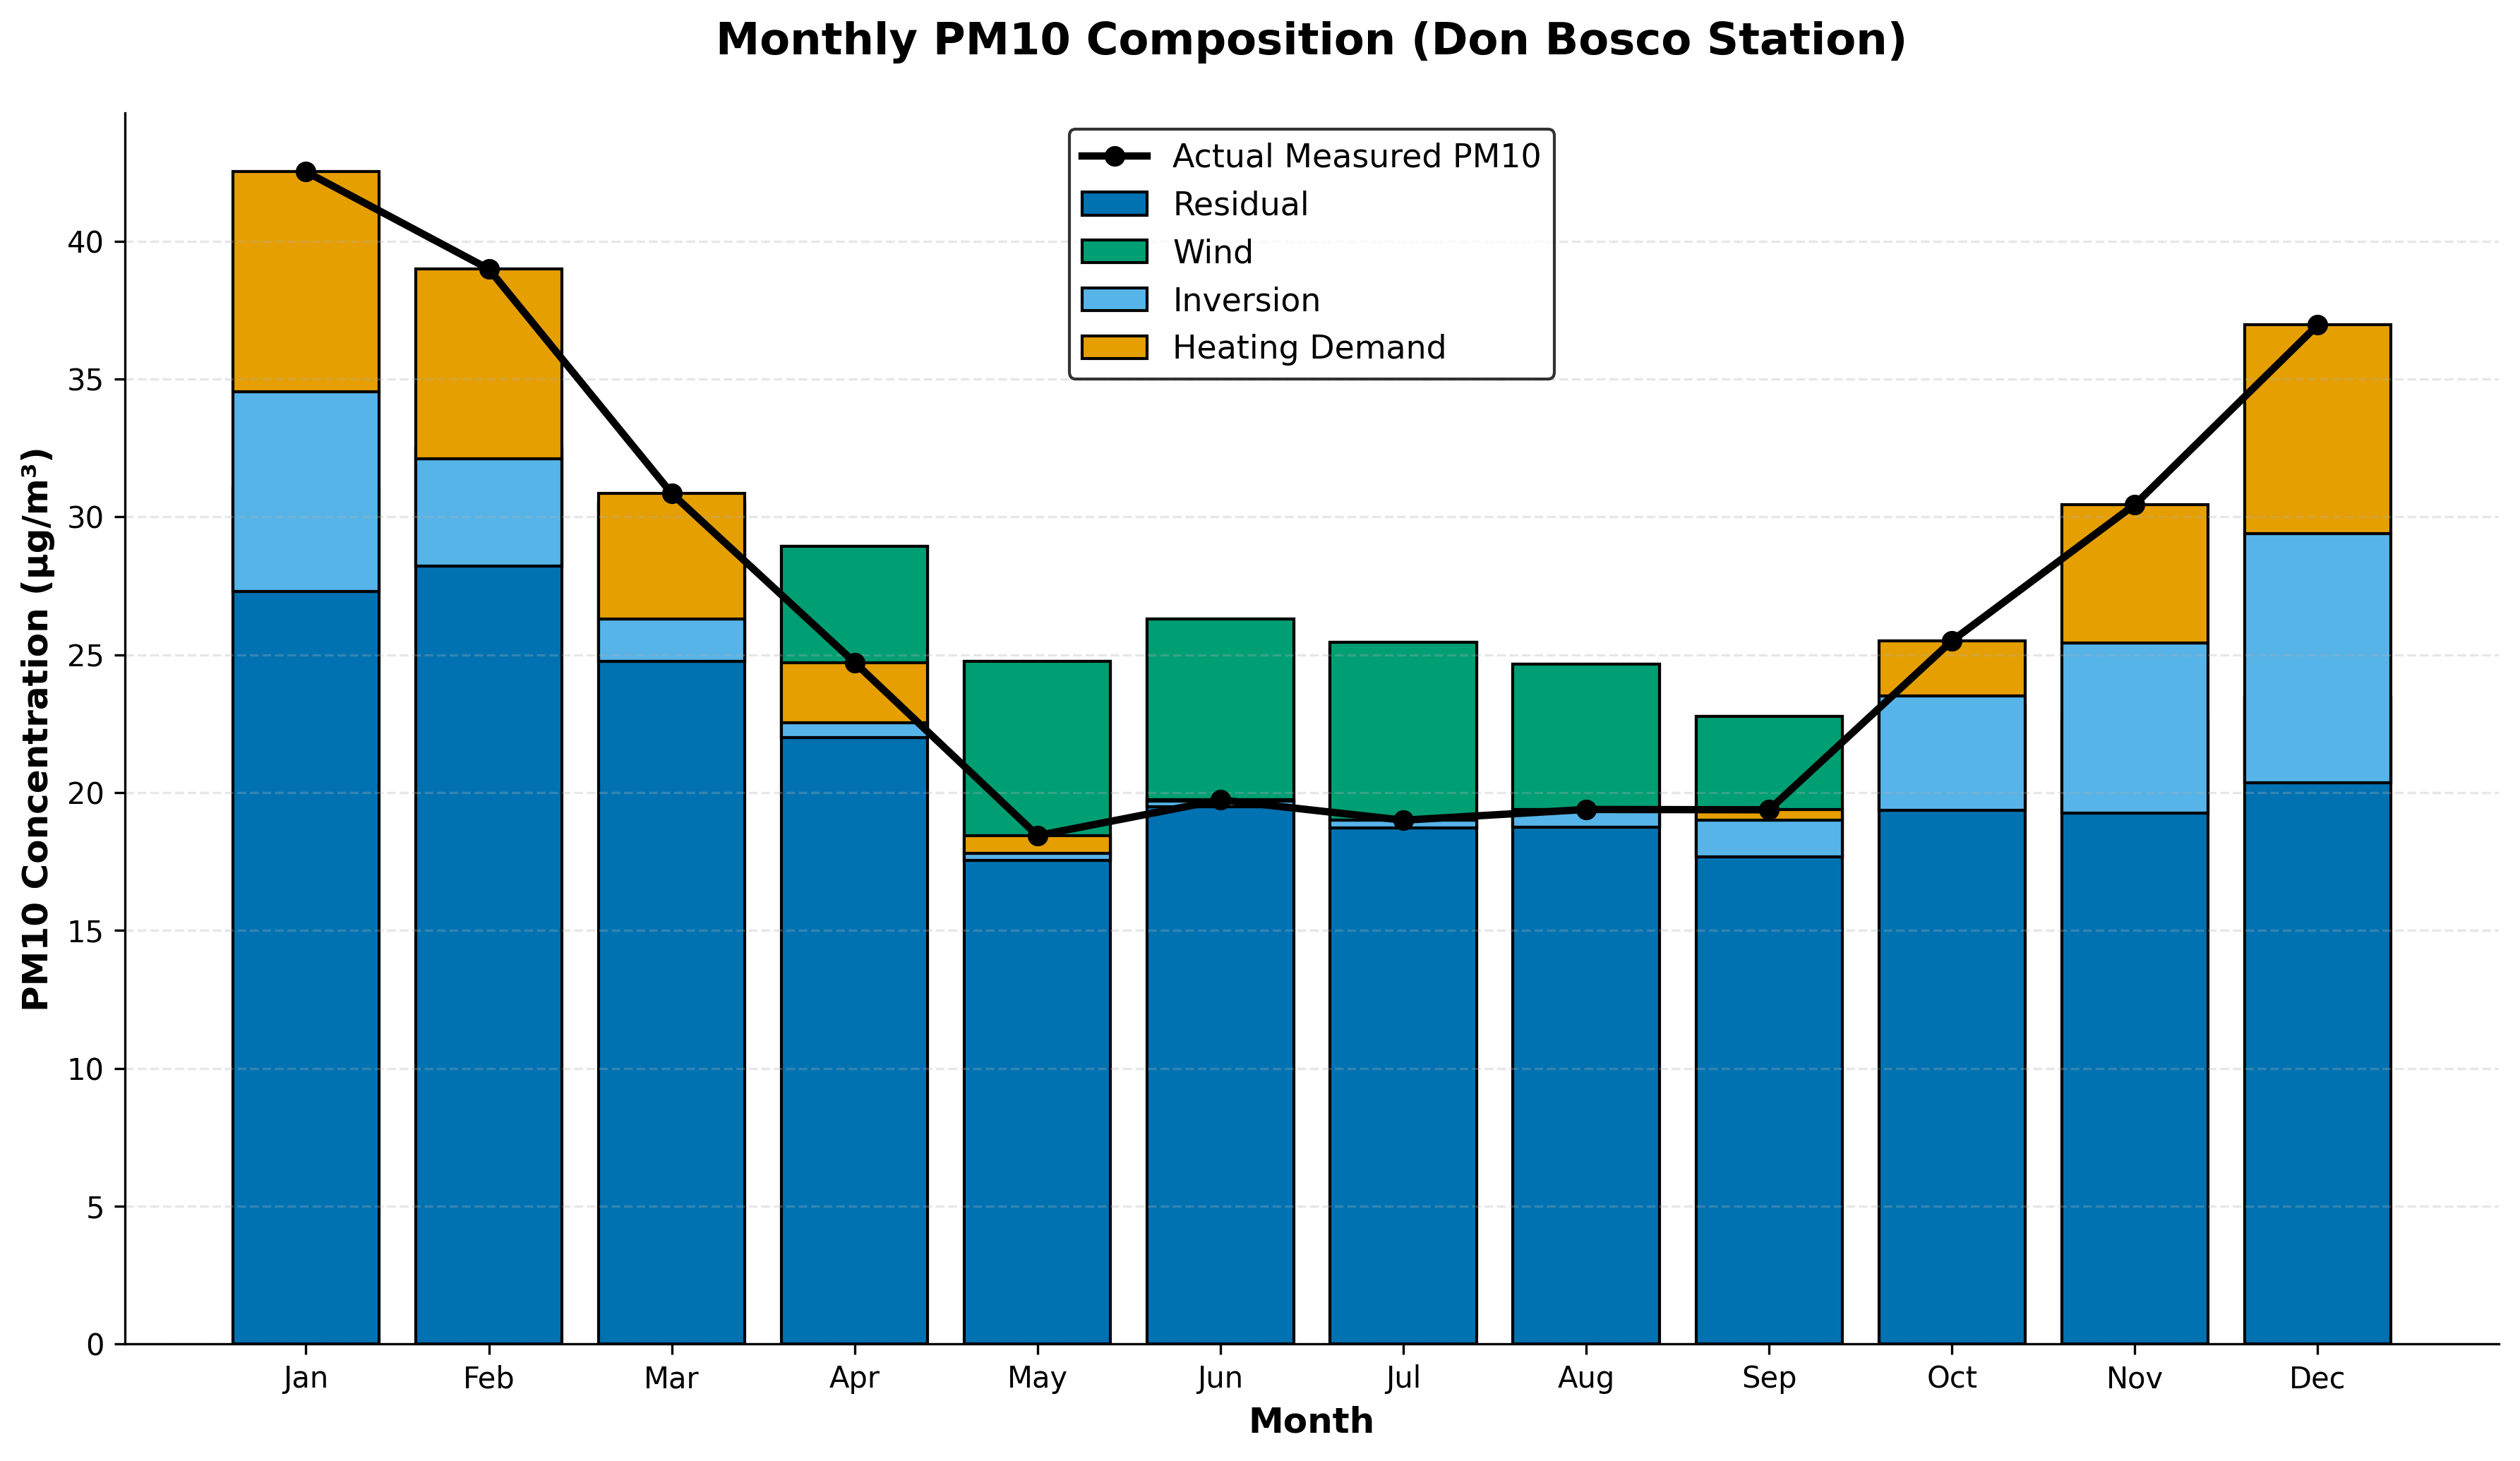

In [71]:


display(df_monthly.round(2))
fig, ax = plt.subplots(figsize=(12, 7),  dpi=300)

# Vibrant Colorblind-Safe Palette
color_base = '#0072B2'      # Dark Blue
color_heating = '#E69F00'   # Orange
color_inversion = '#56B4E9' # Sky Blue
color_wind = '#009E73'     # Green

# 1. THE HEATING (Bottom Layer)
# 3. THE DYNAMIC BASELINE (Top Layer)
ax.bar(month_names, df_monthly['Baseline_and_Unexplained'], 
       color=color_base, edgecolor='black', linewidth=1, 
       label='Residual')

# 2. THE WIND (Third Layer)
ax.bar(month_names, df_monthly['Wind_Added'], 
       bottom=df_monthly['Baseline_and_Unexplained'],
       color=color_wind, edgecolor='black', linewidth=1,
       label='Wind')

# 2. THE INVERSION (Middle Layer)
ax.bar(month_names, df_monthly['Inversion_Added'], 
       bottom=df_monthly['Baseline_and_Unexplained'] + df_monthly['Wind_Added'],
       color=color_inversion, edgecolor='black', linewidth=1,
       label='Inversion')

ax.bar(month_names, df_monthly['Heating_Added'], 
       bottom=df_monthly['Baseline_and_Unexplained'] + df_monthly['Wind_Added'] + df_monthly['Inversion_Added'],
       color=color_heating, edgecolor='black', linewidth=1,
       label='Heating Demand')




# 4. ACTUAL MEASURED PM10 (The solid line tracing the top)
ax.plot(month_names, df_monthly['PM10_Valley'], 
        color='black', marker='o', markersize=6, linewidth=2.5, linestyle='-', 
        label='Actual Measured PM10')

# Formatting
ax.set_title('Monthly PM10 Composition (Don Bosco Station)', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('PM10 Concentration (µg/m³)', fontsize=12, fontweight='bold')

# Ensure the line appears in the legend alongside the bar blocks
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.legend(loc='upper center', frameon=True, edgecolor='black', facecolor='white', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


--- ANNUAL MASS BALANCE CONTRIBUTIONS (µg/m³) ---
      Baseline  Heating_Added  Inversion_Added  Wind_Added  PM10_Valley
Date                                                                   
2012     31.88           3.34             2.76       -5.10        32.87
2013     31.53           3.68             2.77       -5.33        32.65
2014     27.50           2.67             2.70       -4.97        27.90
2015     29.18           3.02             3.24       -5.16        30.28
2016     26.07           3.19             2.92       -5.18        26.99
2017     31.22           3.33             3.07       -5.38        32.25
2018     30.67           4.30             2.74       -4.57        33.13
2019     25.20           2.88             2.41       -5.19        25.30
2020     23.32           2.76             3.54       -5.45        24.17
2021     23.45           2.89             2.37       -5.07        23.63
2022     23.75           3.05             3.03       -5.12        24.71
2023     21.9

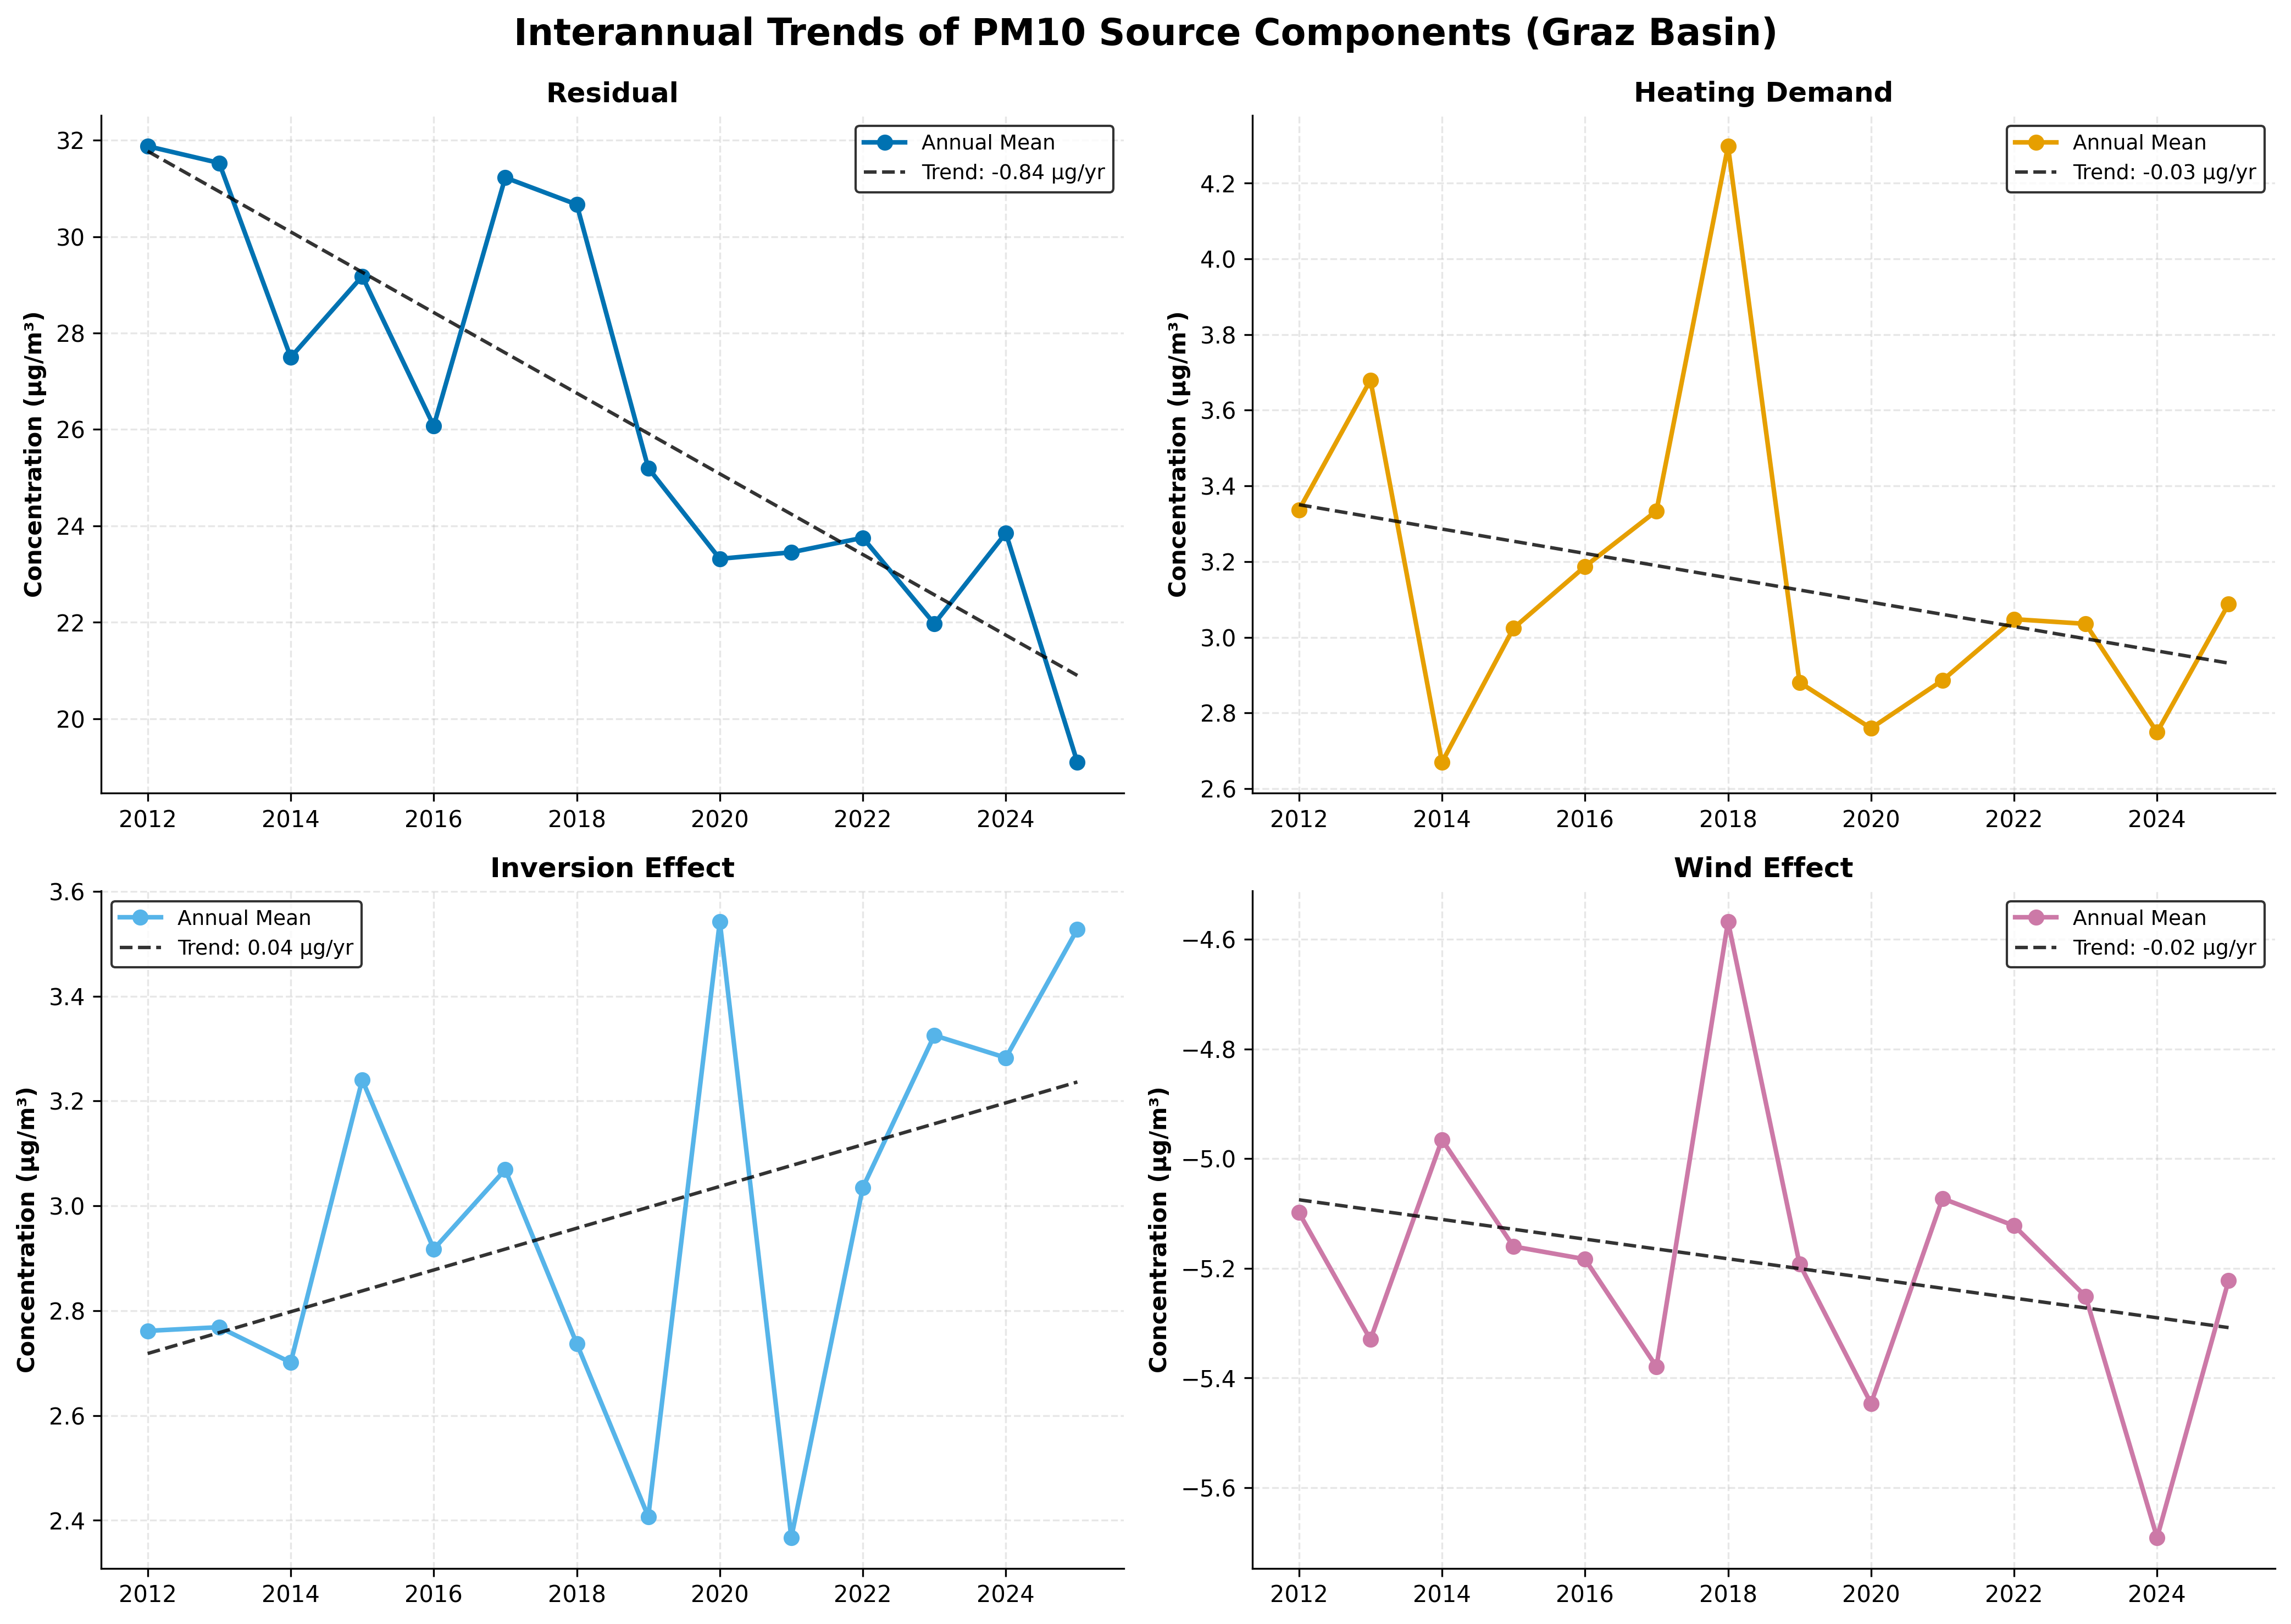

In [72]:


# 1. Calculate the absolute contributions (using your established coefficients)
#df_clean['Heating_Added'] = df_clean['Heating_Demand'] * beta_heat
#df_clean['Inversion_Added'] = df_clean['Inversion_Strength'] * beta_inv
#df_clean['Wind_Added'] = df_clean['Wind_Valley'] * beta_wind

# 2. Group by YEAR instead of month for long-term trends
df_annual = df_clean[['PM10_Valley', 'Heating_Added', 'Inversion_Added', 'Wind_Added']].groupby(df_clean.index.year).mean()

# 3. Calculate the Annual Baseline
df_annual['Baseline'] = df_annual['PM10_Valley'] - (df_annual['Heating_Added'] + df_annual['Inversion_Added'] + df_annual['Wind_Added'])

# Display the tabular data
print("\n--- ANNUAL MASS BALANCE CONTRIBUTIONS (µg/m³) ---")
print(df_annual[['Baseline', 'Heating_Added', 'Inversion_Added', 'Wind_Added', 'PM10_Valley']].round(2))

# ==========================================
# VISUALIZATION: Multi-Panel Trend Plot
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=300)
fig.suptitle('Interannual Trends of PM10 Source Components (Graz Basin)', fontsize=16, fontweight='bold', y=0.98)

# Colorblind-Safe Palette
color_base = '#0072B2'      # Dark Blue
color_heating = '#E69F00'   # Orange
color_inversion = '#56B4E9' # Sky Blue
color_wind = '#CC79A7'      # Reddish Purple

# Map components to their respective subplots
plot_configs = [
    ('Baseline', 'Residual', color_base, axes[0, 0]),
    ('Heating_Added', 'Heating Demand', color_heating, axes[0, 1]),
    ('Inversion_Added', 'Inversion Effect', color_inversion, axes[1, 0]),
    ('Wind_Added', 'Wind Effect', color_wind, axes[1, 1])
]

# Iterate and plot each component
for col, title, color, ax in plot_configs:
    # Plot the raw annual averages
    ax.plot(df_annual.index, df_annual[col], marker='o', markersize=6, color=color, linewidth=2, label='Annual Mean')
    
    # Calculate and plot the linear trendline
    z = np.polyfit(df_annual.index, df_annual[col], 1)
    p = np.poly1d(z)
    ax.plot(df_annual.index, p(df_annual.index), color='black', linestyle='--', linewidth=1.5, alpha=0.8, label=f'Trend: {z[0]:.2f} µg/yr')
    
    # Formatting
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Concentration (µg/m³)', fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True)) # Force integer years on X-axis
    ax.legend(loc='best', frameon=True, facecolor='white', edgecolor='black', fontsize=9)

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Make room for the main title
plt.show()

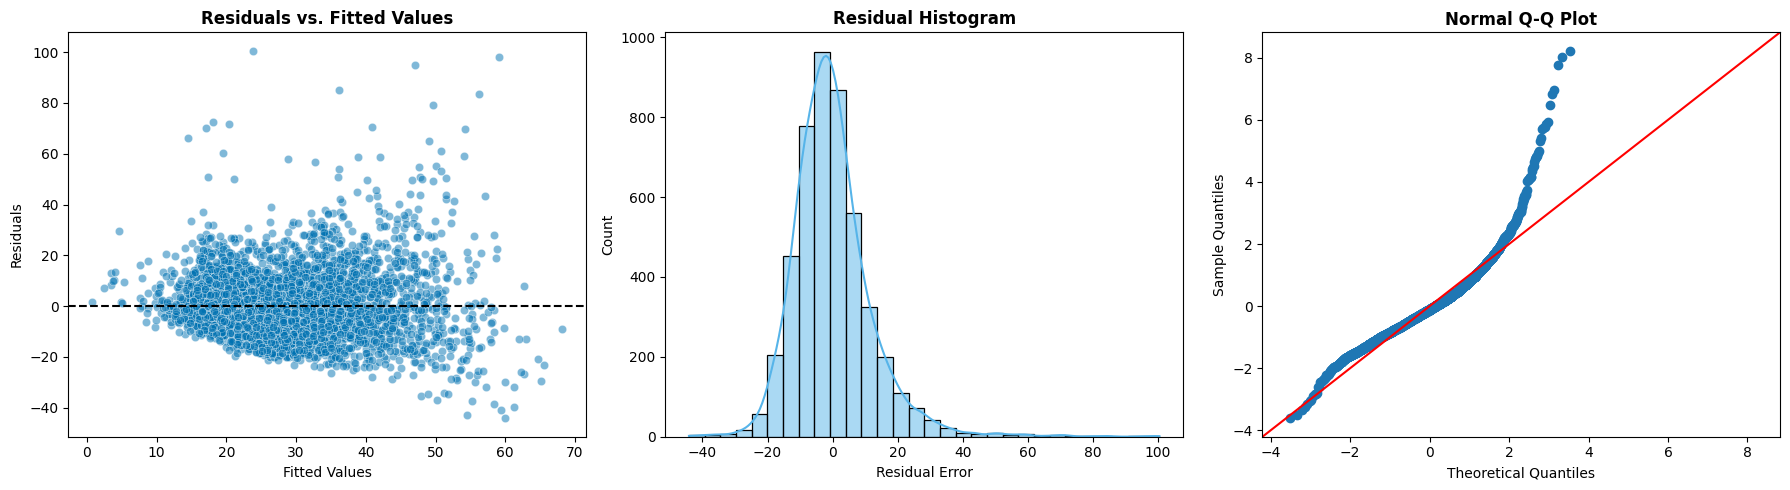

Jarque-Bera p-value: 0.0000
Result: Residuals are NOT normally distributed (Reject Null Hypothesis).


In [73]:

import statsmodels.api as sm
import seaborn as sns

# Assuming 'model' is your fitted statsmodels OLS object
residuals = model.resid
fitted_values = model.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=100)

# 1. Residuals vs Fitted (Checking for random scatter / constant variance)
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0], alpha=0.5, color='#0072B2')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_title('Residuals vs. Fitted Values', fontweight='bold')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# 2. Histogram & KDE (Checking for the bell curve)
sns.histplot(residuals, kde=True, ax=axes[1], color='#56B4E9', bins=30)
axes[1].set_title('Residual Histogram', fontweight='bold')
axes[1].set_xlabel('Residual Error')

# 3. Q-Q Plot (Checking strictly for normality)
sm.qqplot(residuals, line='45', fit=True, ax=axes[2], color='#E69F00')
axes[2].set_title('Normal Q-Q Plot', fontweight='bold')

plt.tight_layout()
plt.show()

# Quantitative Output
jb_stat, jb_pvalue, skew, kurtosis = sm.stats.stattools.jarque_bera(residuals)
print(f"Jarque-Bera p-value: {jb_pvalue:.4f}")
if jb_pvalue < 0.05:
    print("Result: Residuals are NOT normally distributed (Reject Null Hypothesis).")
else:
    print("Result: Residuals appear normally distributed (Fail to Reject Null Hypothesis).")